In [10]:
#LOAD DATA

import pandas as pd

df = pd.read_csv('tweets.csv', header=None)
df.columns = ['ID', 'Topic', 'Sentiment', 'Tweet']
df.head()

,ID,Topic,Sentiment,Tweet
0,2401,Borderlands,Positive,im getting on borderlands and i will murder yo...
1,2401,Borderlands,Positive,I am coming to the borders and I will kill you...
2,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...
3,2401,Borderlands,Positive,im coming on borderlands and i will murder you...
4,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...


In [11]:
#INSTALL SENTIMENT LIBRARY
import sys
!{sys.executable} -m pip install textblob

Defaulting to user installation because normal site-packages is not writeable


In [12]:
#ENABLE TEXTBLOB

from textblob import download_corpora
download_corpora.download_all()

[nltk_data] Downloading package brown to
[nltk_data]     C:\Users\ADMIN\AppData\Roaming\nltk_data...
[nltk_data]   Package brown is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\ADMIN\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\ADMIN\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     C:\Users\ADMIN\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package conll2000 to
[nltk_data]     C:\Users\ADMIN\AppData\Roaming\nltk_data...
[nltk_data]   Package conll2000 is already up-to-date!
[nltk_data] Downloading package movie_reviews to
[nltk_data]     C:\Users\ADMIN\AppData\Roaming\nltk_data...
[nltk_data]   Package movie_reviews is alr

In [13]:
#PERFORM SENTIMENT ANALYSIS

from textblob import TextBlob

def get_sentiment(text):
    polarity = TextBlob(str(text)).sentiment.polarity
    
    if polarity > 0:
        return 'Positive'
    elif polarity < 0:
        return 'Negative'
    else:
        return 'Neutral'

df['Predicted_Sentiment'] = df['Tweet'].apply(get_sentiment)

In [14]:
#To compare original vs predicted:

df[['Sentiment', 'Predicted_Sentiment']].head()

,Sentiment,Predicted_Sentiment
0,Positive,Neutral
1,Positive,Neutral
2,Positive,Neutral
3,Positive,Neutral
4,Positive,Neutral


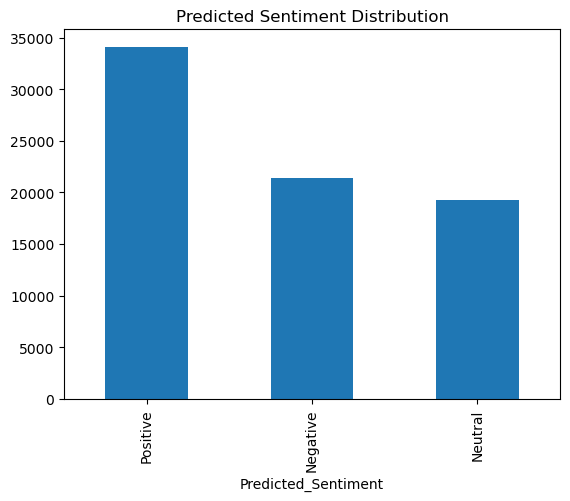

In [15]:
#Bar Chart

import matplotlib.pyplot as plt

df['Predicted_Sentiment'].value_counts().plot(kind='bar')
plt.title('Predicted Sentiment Distribution')

plt.savefig('sentiment_distribution.png')
plt.show()

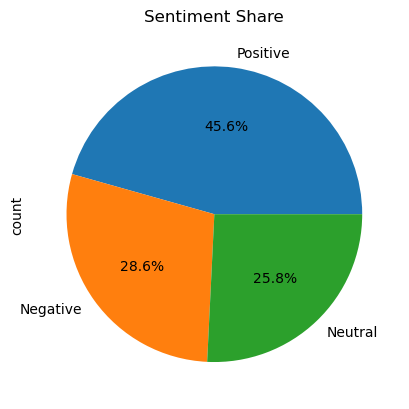

In [16]:
#Pie Chart

df['Predicted_Sentiment'].value_counts().plot(kind='pie', autopct='%1.1f%%')

plt.title('Sentiment Share')
plt.savefig('sentiment_pie.png')
plt.show()

In [17]:
#COUNT SENTIMENT

df['Sentiment'].value_counts()

Sentiment
Negative      22542
Positive      20832
Neutral       18318
Irrelevant    12990
Name: count, dtype: int64